---
title: "STATS 531 project report format\\vspace{-2cm}"
bibliography: references.bib
output: pdf_document
format:
  pdf:
    include-in-header:
      text: |
        \RedeclareSectionCommand[
          beforeskip=0.5em,
          runin=false,
          afterskip=0em
        ]{section}
        \RedeclareSectionCommand[
          beforeskip=0em,
          runin=false,
          afterskip=0em
        ]{subsection}
        \RedeclareSectionCommand[
          beforeskip=0em,
          runin=false,
          afterskip=0em
        ]{subsubsection}
        \usepackage{fullpage}
number-sections: true
jupyter: python3
---



This is a test

In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA


In [2]:
#DETROIT CRIME DATASET
import pandas as pd
crime = pd.read_csv("rms_crime_incidents.csv", comment='#')

crime.head()


C:\Users\enora\AppData\Local\Temp\ipykernel_13104\2156651975.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  crime = pd.read_csv("rms_crime_incidents.csv", comment='#')


,X,Y,incident_entry_id,nearest_intersection,offense_category,offense_description,state_offense_code,arrest_charge,charge_description,incident_occurred_at,...,report_number,scout_car_area,police_precinct,census_block_2020_geoid,neighborhood,council_district,zip_code,longitude,latitude,ESRI_OID
0,-83.241300,42.374040,1255424-2307,Wadsworth St & Fielding St,LARCENY,LARCENY - OTHER ...,2307,23007,LARCENY - OTHER ...,2025/03/11 04:00:00+00,...,2503170044,0603,06,2.616355e+14,Weatherby,7.0,48228.0,-83.241300,42.374040,1.0
1,-83.147703,42.340357,1380965-2601,McDonald St & Radcliffe St,FRAUD,FRAUD - FALSE PRETENSE / SWINDLE / CONFIDENCE ...,2601,26001,FRAUD - FALSE PRETENSE / SWINDLE / CONFIDENCE ...,2025/12/17 17:30:00+00,...,2601020174,0401,04,2.616353e+14,Claytown,6.0,48210.0,-83.147703,42.340357,2.0
2,-83.114223,42.357153,1389365-2900,Seebaldt St & Turner St,DAMAGE TO PROPERTY,DAMAGE TO PROPERTY ...,2900,29000,DAMAGE TO PROPERTY ...,2026/01/27 12:06:00+00,...,2601270059,1006,10,2.616353e+14,Midwest,6.0,48204.0,-83.114223,42.357153,3.0
3,-83.043401,42.424733,1363733-5701,Iowa St & Minnesota St,INVASION OF PRIVACY -OTHER,TRESPASS,5701,57001,TRESPASS,2025/11/17 01:24:00+00,...,2511160321,1108,11,2.616351e+14,Davison,3.0,48212.0,-83.043401,42.424733,4.0
4,-83.043401,42.424733,1363732-1301,Iowa St & Minnesota St,ASSAULT,ASSAULT AND BATTERY/SIMPLE ASSAULT,1301,13001,ASSAULT AND BATTERY/SIMPLE ASSAULT,2025/11/17 01:24:00+00,...,2511160321,1108,11,2.616351e+14,Davison,3.0,48212.0,-83.043401,42.424733,5.0


In [3]:
#crime["date"] = pd.to_datetime(crime["date"], utc=True)
#list(crime.columns)
crime['incident_occurred_at'].head()

crime["date"] = pd.to_datetime(
    crime["incident_occurred_at"],
    utc=True
)

crime_ts = crime[
    (crime["incident_occurred_at"] >= "2017-01-01") &
    (crime["incident_occurred_at"] <  "2026-01-01")
]


monthly_counts = (
    crime_ts
    .set_index("date")
    .resample("MS")         # Month Start
    .size()
    .rename("crime_count")
    .reset_index()
)

print("Monthly points:", len(monthly_counts))

Monthly points: 108


In [4]:
print(crime['date'].min())
monthly_counts.head()

1915-10-17 01:00:00+00:00


,date,crime_count
0,2017-01-01 00:00:00+00:00,6399
1,2017-02-01 00:00:00+00:00,5900
2,2017-03-01 00:00:00+00:00,6691
3,2017-04-01 00:00:00+00:00,6958
4,2017-05-01 00:00:00+00:00,7431


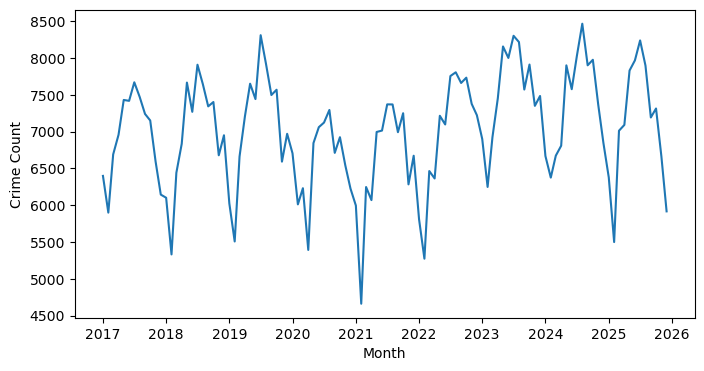

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(monthly_counts['date'], monthly_counts['crime_count'])
plt.xlabel('Month'); plt.ylabel('Crime Count'); plt.show()


In [6]:
crime_ts["year"] = crime_ts["date"].dt.year

crime_ts.groupby("year").size()

C:\Users\enora\AppData\Local\Temp\ipykernel_13104\3040918361.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crime_ts["year"] = crime_ts["date"].dt.year


year
2017    83075
2018    83580
2019    85359
2020    79073
2021    78929
2022    83788
2023    90530
2024    88601
2025    85008
dtype: int64

In [7]:
monthly_counts["crime_count"].describe()

count     108.000000
mean     7017.990741
std       757.812105
min      4662.000000
25%      6580.250000
50%      7095.000000
75%      7570.750000
max      8467.000000
Name: crime_count, dtype: float64

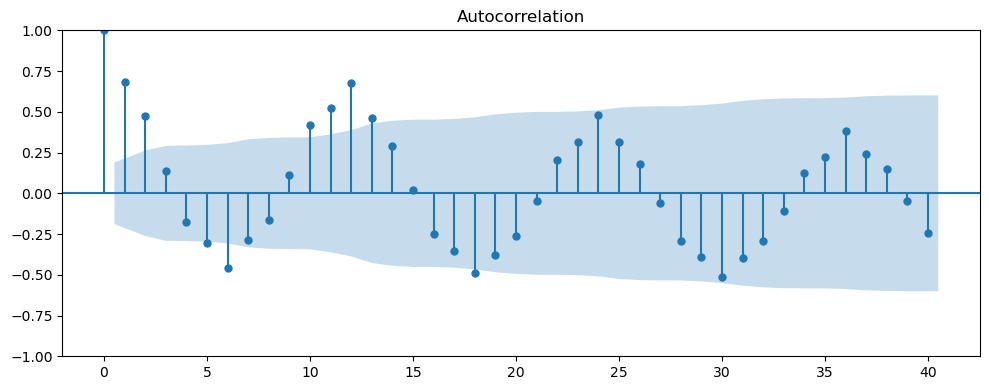

In [8]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(monthly_counts['crime_count'], ax=ax, lags=40)
plt.tight_layout()
plt.show()


Definitely seems like the crime data will work- ARMA model will fail because of seasonality shown clearly in the acf plots, but we can do another model that properly accounts for seasonality and explain why this correction is needed.

<Axes: >

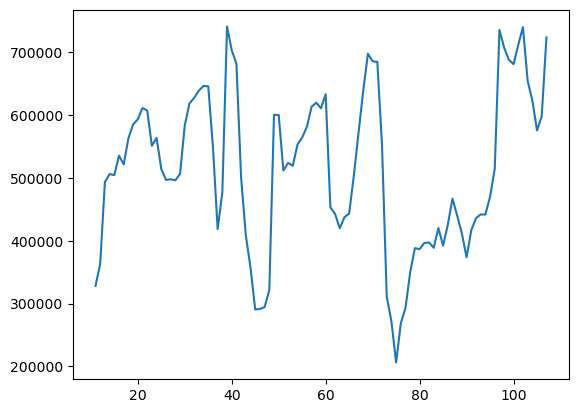

In [9]:
monthly_counts["crime_count"].rolling(12).var().plot()

In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


#creating a covid indicator var
#0 pre covid, 1 during covid, 2 post covid

monthly_counts["covid"] = np.select(
    [
        monthly_counts["date"] < pd.Timestamp("2020-03-01", tz="UTC"),
        (monthly_counts["date"] >= pd.Timestamp("2020-03-01", tz="UTC")) & (monthly_counts["date"] < pd.Timestamp("2022-07-01", tz="UTC")),
        monthly_counts["date"] >= pd.Timestamp("2022-07-01", tz="UTC"),
    ],
    ["pre", "during", "post"],
    default="unknown" 
)



monthly_counts["covid"] = pd.Categorical(
    monthly_counts["covid"],
    categories=["pre", "during", "post"],
    ordered=True
)



In [11]:
X = pd.get_dummies(monthly_counts["covid"], drop_first=True).astype(float)

In [12]:
X.isna().sum()

during    0
post      0
dtype: int64

In [13]:
monthly_counts[monthly_counts["crime_count"].isna()].head(10)

,date,crime_count,covid


In [14]:
#model without seasonal terms
fit1 =SARIMAX(monthly_counts['crime_count'],order=(1,0, 1), seasonal_order=(0,0,0,12), trend='c', exog=X).fit()
print(fit1.aic)
print(fit1.summary().tables[1])

1762.5752288769465
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    108.7786    100.404      1.083      0.279     -88.009     305.566
during      5287.2183    500.241     10.569      0.000    4306.764    6267.672
post        7276.6973    687.819     10.579      0.000    5928.597    8624.797
ar.L1          0.9689      0.025     38.405      0.000       0.919       1.018
ma.L1          0.0437      0.102      0.428      0.668      -0.156       0.243
sigma2      4.428e+05   8.39e+04      5.279      0.000    2.78e+05    6.07e+05


C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [15]:
#considering several possible models with different non-seasonal and seasonal AR/MA lags

#1 AR, 0 MA in both seasonal and non seasonal
fit1 =SARIMAX(monthly_counts['crime_count'],order=(1,0, 0), seasonal_order=(1,0,0,12), trend='c', exog=X).fit()
print(fit1.aic)

#0 AR, 1 MA in both seasonal and non seasonal
fit2 =SARIMAX(monthly_counts['crime_count'],order=(0,0, 1), seasonal_order=(0,0,1,12), trend='c', exog=X).fit()
print(fit2.aic)

#1 AR, 1 MA in both seasonal and non seasonal
fit3 =SARIMAX(monthly_counts['crime_count'],order=(1,0, 1), seasonal_order=(1,0,1,12), trend='c', exog=X).fit()
print(fit3.aic)

#2 AR, 1 MA in both seasonal and non seasonal
fit4 =SARIMAX(monthly_counts['crime_count'],order=(2,0, 1), seasonal_order=(2,0,1,12), trend='c', exog=X).fit()
print(fit4.aic)

C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


1767.6261618339724


C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


1885.3757787126945


C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


1774.8163285165876
1776.538593957242


C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [16]:
fit1 =SARIMAX(monthly_counts['crime_count'],order=(1,0, 0), seasonal_order=(1,0,0,12), trend='c', exog=X).fit()
print(fit1.aic)

1767.6261618339724


C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [17]:
res = fit1

# Parameter vector
params = res.params

# Indices for different components
sar_idx = res.model._spec.seasonal_ar_lags
ar_idx  = res.model._spec.ar_lags

print("Nonseasonal AR lags:", ar_idx)
print("Seasonal AR lags:", sar_idx)

phi = params[ar_idx]     # nonseasonal AR params
Phi = params[sar_idx]    # seasonal AR params

Nonseasonal AR lags: [1]
Seasonal AR lags: [1]


C:\Users\enora\AppData\Local\Temp\ipykernel_13104\2378778628.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  phi = params[ar_idx]     # nonseasonal AR params
C:\Users\enora\AppData\Local\Temp\ipykernel_13104\2378778628.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Phi = params[sar_idx]    # seasonal AR params


In [18]:
s = res.model.seasonal_periods

# ---- Nonseasonal AR: 1 - phi L
ar_ns_poly = np.r_[1, -phi]
ar_ns_roots = np.roots(ar_ns_poly[::-1])

# ---- Seasonal AR: 1 - Phi L^s
coef_sar = np.zeros(s + 1)
coef_sar[0] = 1.0
coef_sar[s] = -Phi[0]

sar_roots = np.roots(coef_sar[::-1])

# ---- Full AR = product
ar_full_poly = np.convolve(ar_ns_poly, coef_sar)
ar_full_roots = np.roots(ar_full_poly[::-1])

print("Nonseasonal AR roots:", ar_ns_roots)
print("Seasonal AR roots:", sar_roots)
print("Full AR roots:", ar_full_roots)
print("Inverse full AR roots:", 1 / ar_full_roots)

Nonseasonal AR roots: [0.00017263]
Seasonal AR roots: [-4.85764992e-01+0.j         -4.20684823e-01+0.2428825j
 -4.20684823e-01-0.2428825j  -2.42882496e-01+0.42068482j
 -2.42882496e-01-0.42068482j -2.61293404e-16+0.48576499j
 -2.61293404e-16-0.48576499j  2.42882496e-01+0.42068482j
  2.42882496e-01-0.42068482j  4.85764992e-01+0.j
  4.20684823e-01+0.2428825j   4.20684823e-01-0.2428825j ]
Full AR roots: [-4.85764992e-01+0.j         -4.20684823e-01+0.2428825j
 -4.20684823e-01-0.2428825j  -2.42882496e-01+0.42068482j
 -2.42882496e-01-0.42068482j  1.98668639e-16+0.48576499j
  1.98668639e-16-0.48576499j  2.42882496e-01+0.42068482j
  2.42882496e-01-0.42068482j  4.85764992e-01+0.j
  4.20684823e-01+0.2428825j   4.20684823e-01-0.2428825j
  1.72629316e-04+0.j        ]
Inverse full AR roots: [-2.05860862e+00-0.j         -1.78280736e+00-1.02930431j
 -1.78280736e+00+1.02930431j -1.02930431e+00-1.78280736j
 -1.02930431e+00+1.78280736j  8.41931758e-16-2.05860862j
  8.41931758e-16+2.05860862j  1.02930431e

C:\Users\enora\AppData\Local\Temp\ipykernel_13104\3942612342.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef_sar[s] = -Phi[0]


In [19]:
fit1 =SARIMAX(monthly_counts['crime_count'],order=(2,0, 0), seasonal_order=(2,0,0,12), trend='c', exog=X).fit()
print(fit1.aic)

1746.6869957103347


C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [20]:
print(fit1.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    169.1692    168.993      1.001      0.317    -162.051     500.389
during      2878.6384    498.293      5.777      0.000    1902.001    3855.275
post        7063.2605    877.874      8.046      0.000    5342.659    8783.862
ar.L1          0.9001      0.159      5.658      0.000       0.588       1.212
ar.L2          0.0165      0.181      0.091      0.927      -0.339       0.372
ar.S.L12       0.2279      0.147      1.552      0.121      -0.060       0.516
ar.S.L24       0.1990      0.150      1.331      0.183      -0.094       0.492
sigma2       7.18e+05   1.78e+05      4.039      0.000     3.7e+05    1.07e+06


C:\Users\enora\AppData\Local\Temp\ipykernel_13104\1628714318.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Phi_val = float(res.params[res.param_names.index("ar.S.L12")])


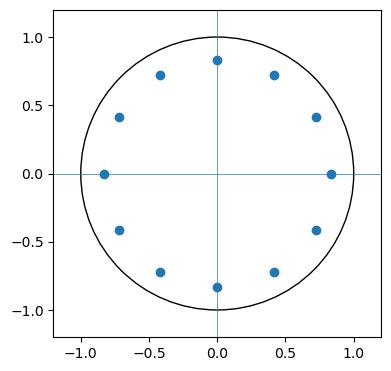

In [21]:
Phi_val = float(res.params[res.param_names.index("ar.S.L12")])
s = 12

sar_poly = np.zeros(s + 1)
sar_poly[0] = 1.0
sar_poly[s] = -Phi_val

sar_roots = np.roots(sar_poly[::-1])
inv_sar_roots = 1 / sar_roots

import matplotlib.patches as patches
fig, ax = plt.subplots(figsize=(4, 4))
ax.add_patch(patches.Circle((0, 0), radius=1, edgecolor="black", facecolor="None"))

ax.scatter(inv_sar_roots.real, inv_sar_roots.imag)

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.axhline(0, linewidth=0.5)
ax.axvline(0, linewidth=0.5)

plt.tight_layout()
plt.show()

Seasonal AR terms: {'ar.S.L12': 0.22794985431208142, 'ar.S.L24': 0.19903776286638156}


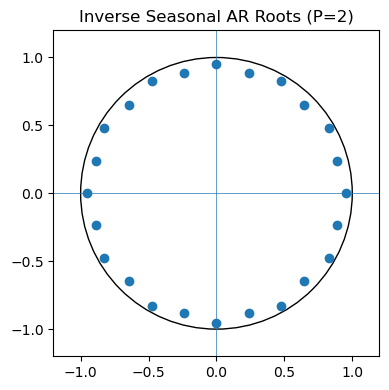

In [22]:
#CORRECT CODE CHUNK
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# pull seasonal AR terms from fit1
phiS = {name: float(fit1.params[name])
        for name in fit1.param_names
        if name.startswith("ar.S.L")}

print("Seasonal AR terms:", phiS)   # expect L12 and L24

maxlag = max(int(k.split("L")[-1]) for k in phiS)
sar_poly = np.zeros(maxlag + 1)
sar_poly[0] = 1.0
for name, val in phiS.items():
    lag = int(name.split("L")[-1])
    sar_poly[lag] = -val

sar_roots = np.roots(sar_poly[::-1])
inv_sar_roots = 1 / sar_roots

fig, ax = plt.subplots(figsize=(4, 4))
ax.add_patch(patches.Circle((0, 0), radius=1, edgecolor="black", facecolor="None"))
ax.scatter(inv_sar_roots.real, inv_sar_roots.imag)

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.axhline(0, linewidth=0.5)
ax.axvline(0, linewidth=0.5)
ax.set_title("Inverse Seasonal AR Roots (P=2)")
plt.tight_layout()
plt.show()

Seasonal AR terms: {'ar.S.L12': 0.11111242506066861}


C:\Users\enora\AppData\Local\Temp\ipykernel_13104\1614124245.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  phiS = {name: float(res.params[i])


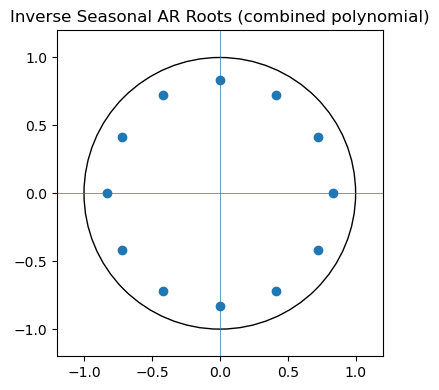

In [23]:
# grab all seasonal AR params that exist (e.g., ar.S.L12, ar.S.L24, ...)
phiS = {name: float(res.params[i])
        for i, name in enumerate(res.param_names)
        if name.startswith("ar.S.L")}

print("Seasonal AR terms:", phiS)

# build polynomial in L up to max seasonal lag
maxlag = max(int(k.split("L")[-1]) for k in phiS.keys())
sar_poly = np.zeros(maxlag + 1)
sar_poly[0] = 1.0

for name, val in phiS.items():
    lag = int(name.split("L")[-1])
    sar_poly[lag] = -val  # 1 - sum(phi_lag * L^lag)

# roots of polynomial in z where poly is reversed for np.roots
sar_roots = np.roots(sar_poly[::-1])
inv_sar_roots = 1 / sar_roots

fig, ax = plt.subplots(figsize=(4, 4))
ax.add_patch(patches.Circle((0, 0), radius=1, edgecolor="black", facecolor="None"))
ax.scatter(inv_sar_roots.real, inv_sar_roots.imag)

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.axhline(0, linewidth=0.5)
ax.axvline(0, linewidth=0.5)

ax.set_title("Inverse Seasonal AR Roots (combined polynomial)")
plt.tight_layout()
plt.show()

In [24]:
print(res.param_names)

phiS = {name: float(res.params[name])
        for name in res.param_names
        if name.startswith("ar.S.L")}

print("Seasonal AR terms found:", phiS)

['intercept', 'during', 'post', 'ar.L1', 'ar.S.L12', 'sigma2']
Seasonal AR terms found: {'ar.S.L12': 0.11111242506066861}


In [25]:
print("Phi =", Phi_val, "abs(Phi) =", abs(Phi_val))
print("expected inverse-root radius =", abs(Phi_val)**(1/s))

Phi = 0.11111242506066861 abs(Phi) = 0.11111242506066861
expected inverse-root radius = 0.8326839982289264


In [26]:
#first model fit seems to be the best (1 AR, 0 MA in both seasonal and non seasonal)
print(fit1.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    169.1692    168.993      1.001      0.317    -162.051     500.389
during      2878.6384    498.293      5.777      0.000    1902.001    3855.275
post        7063.2605    877.874      8.046      0.000    5342.659    8783.862
ar.L1          0.9001      0.159      5.658      0.000       0.588       1.212
ar.L2          0.0165      0.181      0.091      0.927      -0.339       0.372
ar.S.L12       0.2279      0.147      1.552      0.121      -0.060       0.516
ar.S.L24       0.1990      0.150      1.331      0.183      -0.094       0.492
sigma2       7.18e+05   1.78e+05      4.039      0.000     3.7e+05    1.07e+06


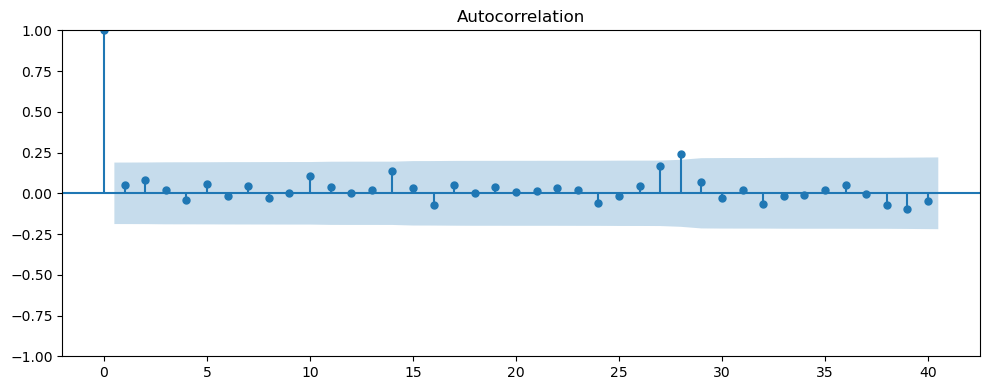

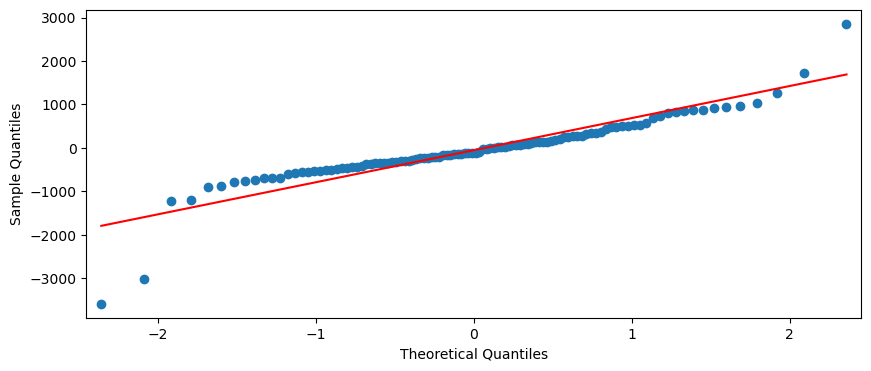

In [27]:
import statsmodels.api as sm
import pylab as py

#ACF of the residuals
resids1 = fit1.resid

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resids1, ax=ax, lags=40)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
sm.qqplot(resids1, line='s', ax=ax)
plt.show()

AR roots: [-55.5005206   1.0892441]
MA root: []


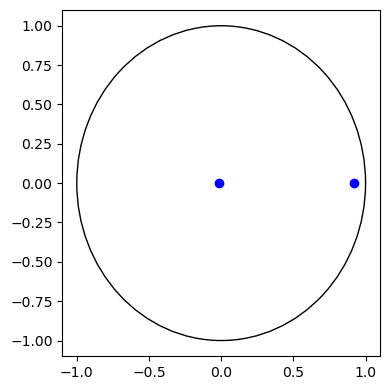

In [28]:


ar_pars = fit1.arparams 
ar_poly = np.polynomial.Polynomial(np.r_[1,-ar_pars]) 
print(f"AR roots: {ar_poly.roots()}")
inv_ar_roots = 1/ar_poly.roots()

ma_pars = fit1.maparams 
ma_poly = np.polynomial.Polynomial(np.r_[1,ma_pars]) 
print(f"MA root: {ma_poly.roots()}")
inv_ma_roots = 1/ma_poly.roots()

fig, ax = plt.subplots(figsize=(4, 4))
unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
ax.add_patch(unit_circle1)
ax.scatter(np.real(inv_ar_roots), np.imag(inv_ar_roots), color='blue', marker='o', label="Inverse AR Roots")

plt.tight_layout()
plt.show()

#root is pretty close to the boundary- should we be concerned?

C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


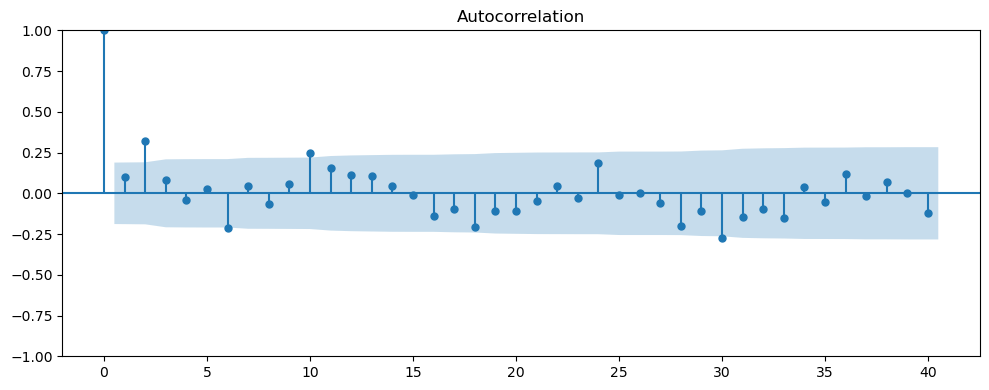

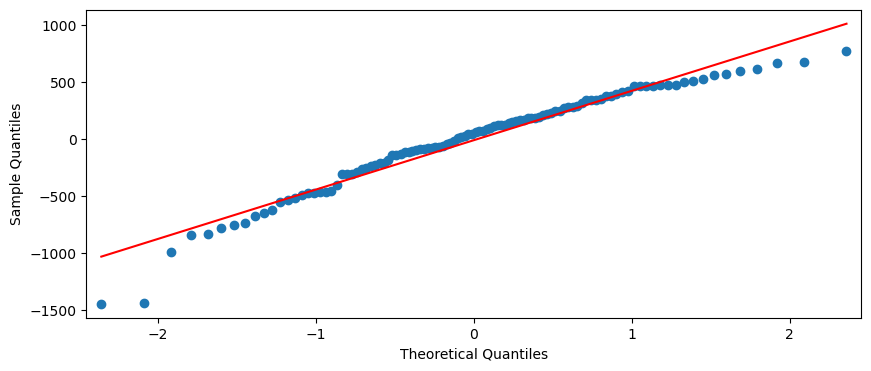

In [29]:
#MODEL WITHOUT COVID AS EXOGENOUS VAR, SHOWS WORSE FIT. INDICATES ADDING COVID VAR HELPED
fit1_nocov =SARIMAX(monthly_counts['crime_count'],order=(1,0, 1), seasonal_order=(1,0,0,12), trend='c').fit()

resids1_nocov = fit1_nocov.resid

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resids1_nocov, ax=ax, lags=40)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
sm.qqplot(resids1_nocov, line='s', ax=ax)
plt.show()

In [30]:
#NOW LOOKING AT UNEMPLOYMENT DATA
from datetime import datetime
unemploy = pd.read_csv("unemployment_wayne_county.csv")
print(unemploy.head())

unemploy = unemploy[unemploy['Year'] >= 2016]

#unemploy["Date"] = pd.to_datetime(unemploy["Label"], format="%Y %b")
#unemploy['Value'] = pd.to_numeric(unemploy['Value'], errors='coerce')

unemploy["date"] = pd.to_datetime(unemploy["Label"], format="%Y %b")

              Series ID  Year Period     Label Value
0  LAUCN261630000000003  2010    M01  2010 Jan  17.1
1  LAUCN261630000000003  2010    M02  2010 Feb  16.8
2  LAUCN261630000000003  2010    M03  2010 Mar  16.9
3  LAUCN261630000000003  2010    M04  2010 Apr  16.0
4  LAUCN261630000000003  2010    M05  2010 May  15.6


In [31]:

unemploy_ts = unemploy.loc[
    (unemploy['date'] >= '2017-01-01') & 
    (unemploy['date'] < '2026-01-01')
].copy()

unemploy_ts["Value"] = pd.to_numeric(unemploy_ts["Value"], errors="coerce")

monthly_unemploy = (
    unemploy_ts
    .set_index("date")['Value']
    .resample("MS")
    .mean()
    .rename("unemploy_rate")
    .reset_index()
)


In [32]:
monthly_unemploy[monthly_unemploy["unemploy_rate"].isna()].head(10)

,date,unemploy_rate
105,2025-10-01,NaN


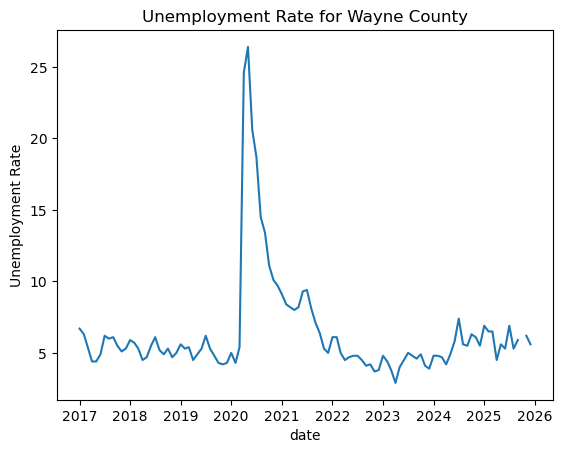

In [33]:
plt.plot(monthly_unemploy["date"], monthly_unemploy["unemploy_rate"])
plt.xlabel("date")
plt.ylabel("Unemployment Rate")
plt.title("Unemployment Rate for Wayne County")

plt.show()

In [34]:


monthly_unemploy.loc[monthly_unemploy["unemploy_rate"].isna(), ["unemploy_rate"]]
#so number 105 is missing 
print(monthly_unemploy.at[105, 'date'])

monthly_unemploy.at[105, "unemploy_rate"] = (monthly_unemploy.at[104, "unemploy_rate"] + monthly_unemploy.at[106, "unemploy_rate"]) / 2
print(monthly_unemploy.at[105, "unemploy_rate"])


2025-10-01 00:00:00
6.050000000000001


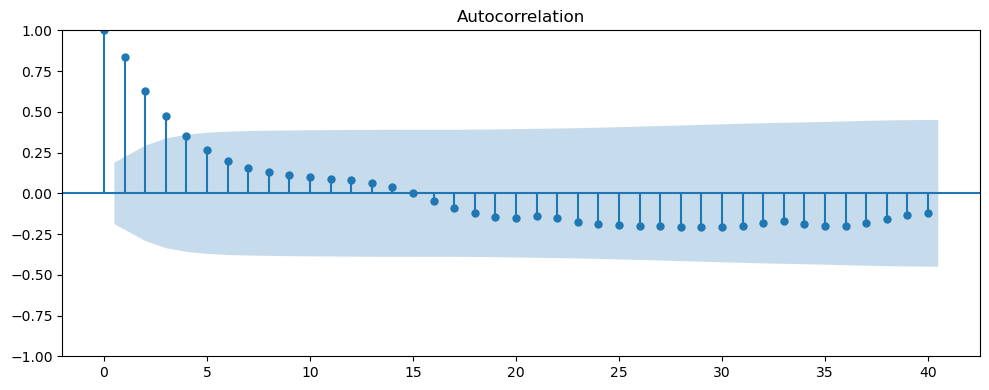

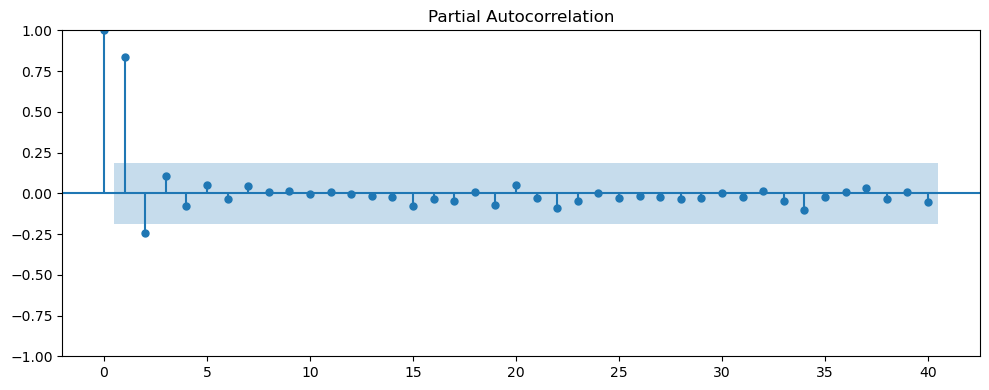

In [35]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(monthly_unemploy["unemploy_rate"], ax=ax, lags=40)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
plot_pacf(monthly_unemploy["unemploy_rate"], ax=ax, lags=40)
plt.tight_layout()
plt.show()

In [36]:
#creating a covid indicator var
#0 pre covid, 1 during covid, 2 post covid

monthly_unemploy["covid"] = np.select(
    [
        monthly_unemploy["date"] < pd.Timestamp("2020-03-01"),
        (monthly_unemploy["date"] >= pd.Timestamp("2020-03-01")) & (monthly_unemploy["date"] < pd.Timestamp("2022-07-01")),
        monthly_unemploy["date"] >= pd.Timestamp("2022-07-01"),
    ],
    ["pre", "during", "post"],
    default="unknown" 
)



monthly_unemploy["covid"] = pd.Categorical(
    monthly_unemploy["covid"],
    categories=["pre", "during", "post"],
    ordered=True
)

In [37]:
# monthly_unemploy = monthly_unemploy.sort_index()
monthly_unemploy = monthly_unemploy.sort_values("date").set_index("date")
# monthly_unemploy = monthly_unemploy.asfreq("MS")
monthly_unemploy["covid"] = monthly_unemploy["covid"].ffill()

In [38]:
X = pd.get_dummies(monthly_unemploy["covid"], drop_first=True).astype(float)

In [39]:
df_model = pd.concat([monthly_unemploy["unemploy_rate"].rename("y"), X], axis=1).dropna()
y = df_model["y"]
X = df_model.drop(columns="y")

In [40]:
#https://www.geeksforgeeks.org/artificial-intelligence/what-is-an-arimax-model/
#fit5 =SARIMAX(monthly_unemploy["unemploy_rate"],order=(1,0, 1), trend='c', exog = X).fit()
fit5 = SARIMAX(y, order=(1,0,1), trend="c", exog=X).fit()
print(fit5.aic)

462.38820727494567


C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [41]:
 print(fit5.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.8806      1.549      1.214      0.225      -1.156       4.917
during        -3.9805      0.895     -4.445      0.000      -5.736      -2.225
post          -3.8611      5.444     -0.709      0.478     -14.531       6.809
ar.L1          0.7876      0.121      6.531      0.000       0.551       1.024
ma.L1          0.4972      0.157      3.158      0.002       0.189       0.806
sigma2         3.7235      0.446      8.358      0.000       2.850       4.597


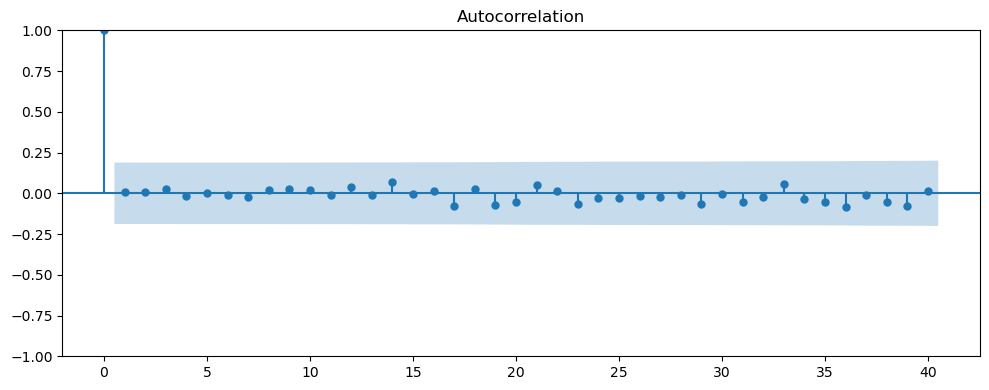

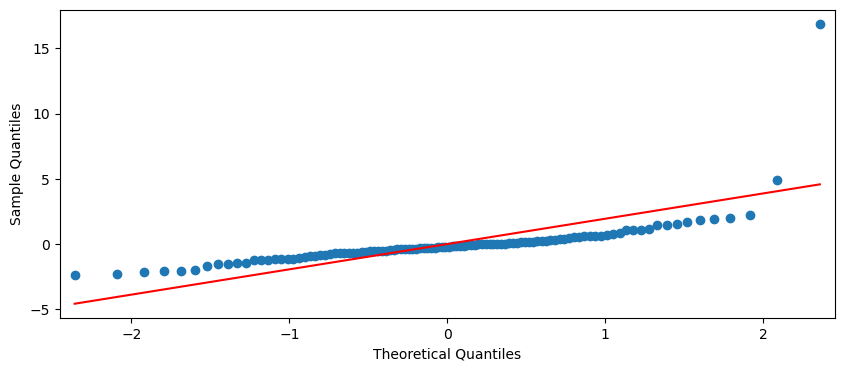

In [42]:
resids5 = fit5.resid

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resids5, ax=ax, lags=40)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
sm.qqplot(resids5, line='s', ax=ax)
plt.show()

In [43]:
#FIT SAME MODEL BUT LOG OF UNEMPLOYMENT TO TRY TO IMRPOVE QQ PLOT/NORMALITY OF RESIDUALS
fit6 = SARIMAX(np.log(y), order=(1,0,1), trend="c", exog=X).fit()
print(fit6.aic)

-42.11063824869801


C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


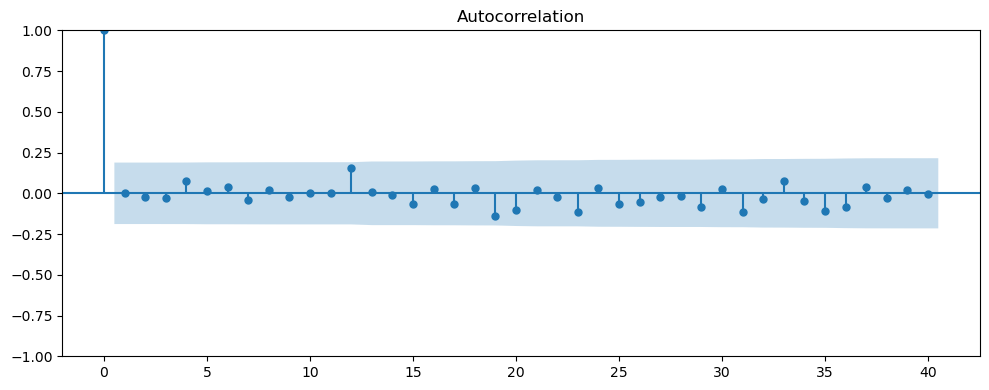

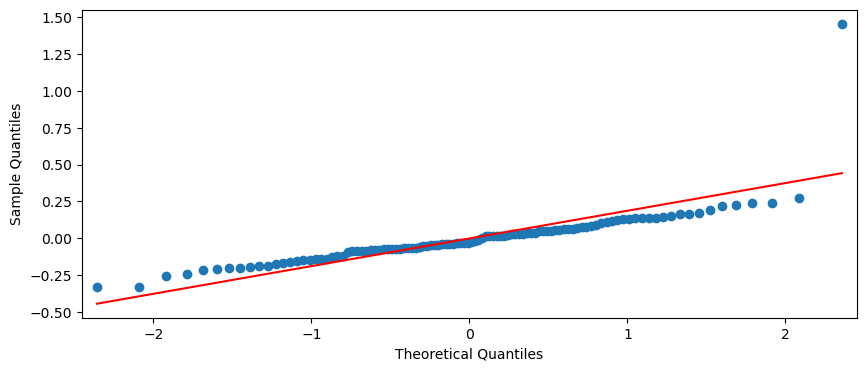

In [44]:
resids6 = fit6.resid

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resids6, ax=ax, lags=40)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
sm.qqplot(resids6, line='s', ax=ax)
plt.show()

In [45]:
print(res.params)          # values
print(res.param_names)     # names in the same order

intercept       131.673292
during         5792.758854
post           7315.908688
ar.L1             0.957674
ar.S.L12          0.111112
sigma2       487181.177515
dtype: float64
['intercept', 'during', 'post', 'ar.L1', 'ar.S.L12', 'sigma2']


In [46]:
Phi_val = float(res.params[res.param_names.index("ar.S.L12")])
print("Phi_val =", Phi_val)

Phi_val = 0.11111242506066861


C:\Users\enora\AppData\Local\Temp\ipykernel_13104\1507676163.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Phi_val = float(res.params[res.param_names.index("ar.S.L12")])


In [47]:
#NEW WORK FROM 2/12/2026

In [48]:
X = pd.get_dummies(monthly_counts["covid"], drop_first=True).astype(float)

In [49]:
monthly_unemploy.head()

,unemploy_rate,covid
date,,
2017-01-01,6.7,pre
2017-02-01,6.3,pre
2017-03-01,5.4,pre
2017-04-01,4.4,pre
2017-05-01,4.4,pre


In [50]:
mc = monthly_counts.copy()
mc.index = pd.date_range("2017-01-01", periods=len(mc), freq="MS")  

In [51]:
# ----- y with real dates -----
y = mc["crime_count"].rename("y")
y.index = y.index.to_period("M").to_timestamp(how="start")
idx_m = y.index.to_period("M")

# ----- dummies -----
X_arr = np.asarray(X)
X_df = pd.DataFrame(X_arr[:, :2], index=idx_m, columns=["during","post"])

# ----- unemployment (already date-indexed) -----
u = monthly_unemploy["unemploy_rate"].copy()
u.index = pd.DatetimeIndex(u.index).to_period("M")
u = u.reindex(idx_m)

# ----- exog -----
exog_data = pd.concat([X_df, u.rename("unemploy_rate")], axis=1)
exog_dt = exog_data.copy()
exog_dt.index = exog_dt.index.to_timestamp(how="start")

print(exog_data.isna().sum())         # should be all zeros now
print(exog_dt.index.equals(y.index))  # should be True

# ----- df0 (aligned master frame) -----
df0 = pd.concat([y, exog_dt], axis=1).dropna()
y_aligned = df0["y"]
X_aligned = df0.drop(columns="y")

during           0
post             0
unemploy_rate    0
dtype: int64
True


In [52]:
y_aligned = df0["y"]
exog_aligned = df0.drop(columns="y")

In [53]:
print(y_aligned.head())
print(exog_aligned.head())


2017-01-01    6399
2017-02-01    5900
2017-03-01    6691
2017-04-01    6958
2017-05-01    7431
Freq: MS, Name: y, dtype: int64
            during  post  unemploy_rate
2017-01-01     0.0   0.0            6.7
2017-02-01     0.0   0.0            6.3
2017-03-01     0.0   0.0            5.4
2017-04-01     0.0   0.0            4.4
2017-05-01     0.0   0.0            4.4


In [54]:

#unemployment_level = unemployment['Value'].values

def sarima_aic_table(data, p_max, q_max, P_max, Q_max, m): # D = 1
    results = []
    # parallelize
    # Iterate through all combinations
    for p in range(p_max + 1):
        for q in range(q_max + 1):
            for P in range(P_max + 1):
                for Q in range(Q_max + 1):
                    try:
                        model = SARIMAX(data, order=(p,0,q), trend='t',
                        seasonal_order=(P, 0, Q, m), exog=exog_aligned)
                        results_fit = model.fit(disp=False)
                        results.append([p, q, P, Q, results_fit.aic])
                    except:
                        results.append([p, q, P, Q, np.nan])
                        
    # Create DataFrame
    df = pd.DataFrame(results, columns=['AR(p)', 'MA(q)', 'SAR(P)', 'SMA(Q)', 'AIC'])
    df.sort_values(by='AIC')
    # Sort by AIC ascending
    return df.sort_values(by='AIC')

sarima_results3 = sarima_aic_table(y_aligned, 2, 1, 1, 1, 12)

C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximu

In [55]:
sarima_results3

,AR(p),MA(q),SAR(P),SMA(Q),AIC
10,1,0,1,0,1705.362993
8,1,0,0,0,1709.177778
9,1,0,0,1,1719.044022
16,2,0,0,0,1728.601188
12,1,1,0,0,1739.820220
20,2,1,0,0,1785.007121
17,2,0,0,1,1816.348668
14,1,1,1,0,1821.239968
18,2,0,1,0,1821.876348
21,2,1,0,1,1823.158572


In [56]:


new_mod = SARIMAX(
    y_aligned,
    exog=X_aligned,
    order=(1,0,0),
    seasonal_order=(1,0,0,12),
    trend="c"
).fit(disp=False)

C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [57]:
print(new_mod.summary().tables[1])

                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept       213.3324    162.586      1.312      0.189    -105.330     531.995
during         -149.2875    595.833     -0.251      0.802   -1317.099    1018.524
post           3888.9768    770.523      5.047      0.000    2378.778    5399.175
unemploy_rate   -39.6100     47.214     -0.839      0.401    -132.148      52.928
ar.L1             0.9182      0.067     13.623      0.000       0.786       1.050
ar.S.L12          0.5058      0.069      7.300      0.000       0.370       0.642
sigma2         3.267e+05   7.24e+04      4.513      0.000    1.85e+05    4.69e+05


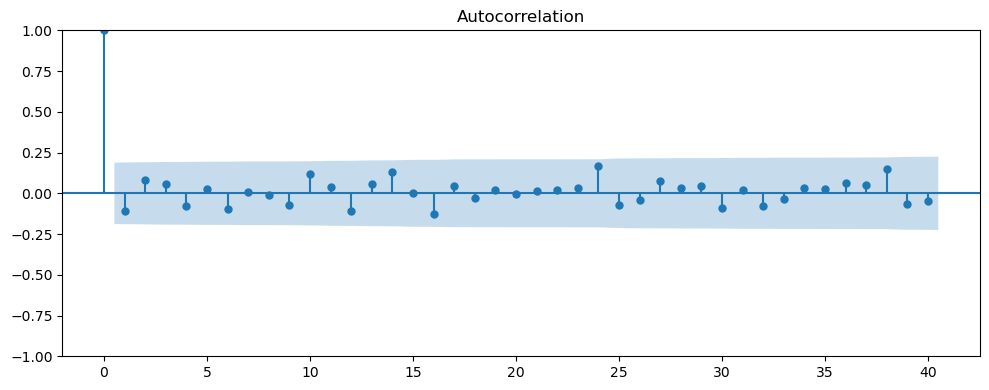

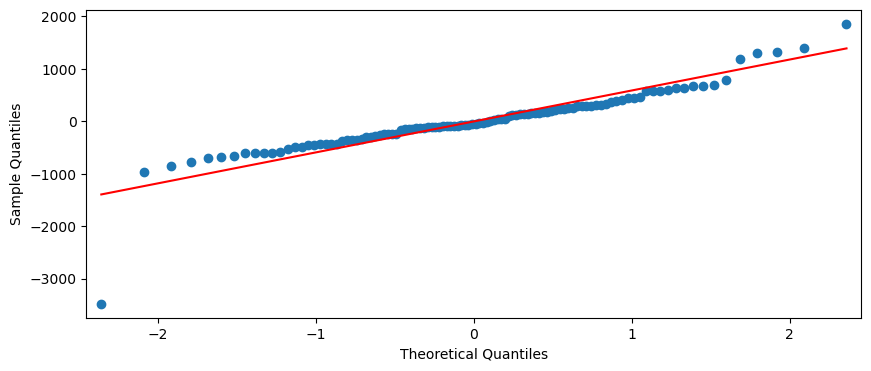

In [58]:
new_resids = new_mod.resid

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(new_resids, ax=ax, lags=40)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
sm.qqplot(new_resids, line='s', ax=ax)
plt.show()

AR roots: [1.08914465]


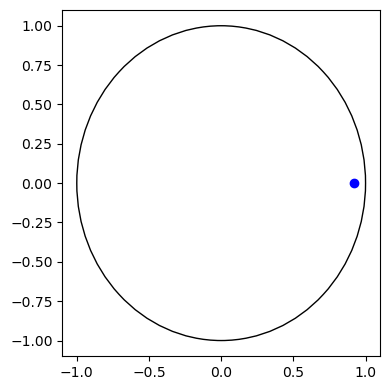

In [59]:
ar_pars = new_mod.arparams 
ar_poly = np.polynomial.Polynomial(np.r_[1,-ar_pars]) 
print(f"AR roots: {ar_poly.roots()}")
inv_ar_roots = 1/ar_poly.roots()

fig, ax = plt.subplots(figsize=(4, 4))
unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
ax.add_patch(unit_circle1)
ax.scatter(np.real(inv_ar_roots), np.imag(inv_ar_roots), color='blue', marker='o', label="Inverse AR Roots")

plt.tight_layout()
plt.show()

Seasonal AR roots: [-1.05844912e+00+0.j         -9.16643829e-01+0.52922456j
 -9.16643829e-01-0.52922456j -5.29224562e-01+0.91664383j
 -5.29224562e-01-0.91664383j  4.15160396e-16+1.05844912j
  4.15160396e-16-1.05844912j  5.29224562e-01+0.91664383j
  5.29224562e-01-0.91664383j  1.05844912e+00+0.j
  9.16643829e-01+0.52922456j  9.16643829e-01-0.52922456j]


C:\Users\enora\AppData\Local\Temp\ipykernel_13104\760638121.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  phi_S12 = new_mod.params[new_mod.param_names.index("ar.S.L12")]


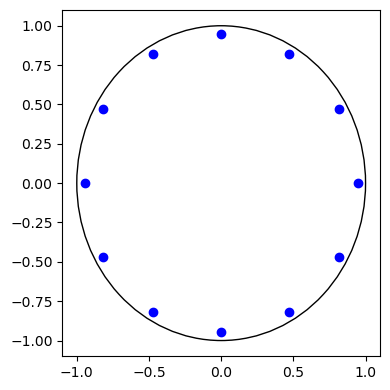

In [60]:

# roots of polynomial in z where poly is reversed for np.roots
phi_S12 = new_mod.params[new_mod.param_names.index("ar.S.L12")]
s = 12

# Build seasonal AR polynomial: 1 - phi * L^12
sar_poly = np.zeros(s + 1)
sar_poly[0] = 1.0
sar_poly[s] = -phi_S12

# Roots and inverse roots
sar_roots = np.roots(sar_poly[::-1])
inv_sar_roots = 1 / sar_roots

print(f"Seasonal AR roots: {sar_roots}")

fig, ax = plt.subplots(figsize=(4, 4))
unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
ax.add_patch(unit_circle1)
ax.scatter(np.real(inv_sar_roots), np.imag(inv_sar_roots), color='blue', marker='o', label="Inverse AR Roots")

plt.tight_layout()
plt.show()